In [1]:
import pandas as pd

In [2]:
data = pd.read_csv(r'C:\Users\gurus\OneDrive\Desktop\study\project\3rd project\youtube_ad_revenue_dataset.csv')
data.shape
data.head(5)
df = data.copy()
df.head(5)

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388


In [3]:
# missing value 
df.isnull().sum()

video_id                   0
date                       0
views                      0
likes                   6117
comments                6112
watch_time_minutes      6105
video_length_minutes       0
subscribers                0
category                   0
device                     0
country                    0
ad_revenue_usd             0
dtype: int64

In [ ]:
# data type 
df.dtypes

In [32]:
#description
df.describe()

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd,year,month,day,watch_revenue_interaction,like_rate,log_views,log_likes,log_comments,log_ad_revenue_usd,month_sin,month_cos,comment_rate
count,122400.000000,122400.000000,122400.000000,122400.000000,122400.000000,122400.000000,122400.000000,122400.000000,122400.000000,122400.000000,1.224000e+05,122400.000000,122400.000000,122400.000000,122400.000000,122400.000000,1.224000e+05,1.224000e+05,122400.000000
mean,9999.856283,1099.634228,274.393380,37544.552098,16.014165,502191.719902,252.727210,2024.435441,6.520482,15.692132,1.024473e+07,0.109957,9.210376,6.864747,5.480525,5.504626,-5.543256e-03,-1.456903e-03,0.027437
std,99.881260,506.279161,126.465157,12660.090977,8.083790,288397.470103,61.957052,0.495817,3.448594,8.784347,5.525711e+06,0.050618,0.009989,0.573687,0.570379,0.255866,7.064825e-01,7.077131e-01,0.012643
min,9521.000000,195.000000,48.000000,14659.105562,2.000142,1005.000000,126.590603,2024.000000,1.000000,1.000000,1.875537e+06,0.019912,9.161360,5.278115,3.891820,4.848827,-1.000000e+00,-1.000000e+00,0.004911
25%,9933.000000,674.000000,168.000000,26956.286217,9.004695,252507.500000,199.902018,2024.000000,4.000000,8.000000,5.446394e+06,0.067358,9.203718,6.514713,5.129899,5.302817,-8.660254e-01,-8.660254e-01,0.016829
50%,10000.000000,1100.462975,274.129487,37561.851898,16.005906,503465.500000,252.749699,2024.000000,7.000000,16.000000,9.484802e+06,0.110016,9.210440,7.004395,5.617242,5.536348,-2.449294e-16,6.123234e-17,0.027411
75%,10067.000000,1524.000000,381.000000,48208.778647,23.021260,752192.000000,305.597518,2025.000000,10.000000,23.000000,1.459352e+07,0.152449,9.217117,7.329750,5.945421,5.725536,5.000000e-01,8.660254e-01,0.038066
max,10468.000000,2061.000000,515.000000,61557.670089,29.999799,999997.000000,382.768254,2025.000000,12.000000,31.000000,2.343919e+07,0.199959,9.256174,7.631432,6.246107,5.950039,1.000000e+00,1.000000e+00,0.049985


In [4]:
df['likes'] = df['likes'].fillna(df.groupby('category')['likes'].transform('mean'))
df['comments'] = df['comments'].fillna(df.groupby(['category','country','device'])['comments'].transform('mean'))
df['watch_time_minutes'] = df['watch_time_minutes'].fillna(df.groupby(['category','country','device'])['watch_time_minutes'].transform('mean'))

In [5]:
df['likes'].dtype
df['likes'].isnull().sum()

0

In [6]:
df.isnull().sum()

video_id                0
date                    0
views                   0
likes                   0
comments                0
watch_time_minutes      0
video_length_minutes    0
subscribers             0
category                0
device                  0
country                 0
ad_revenue_usd          0
dtype: int64

In [7]:
df['date'] = pd.to_datetime(df['date'])
df['date'].dtype
df.date.head(5)

0   2024-09-24 10:50:40.993199
1   2024-09-22 10:50:40.993199
2   2024-11-21 10:50:40.993199
3   2025-01-28 10:50:40.993199
4   2025-04-28 10:50:40.993199
Name: date, dtype: datetime64[ns]

In [8]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['quarter'] = df['date'].dt.quarter

In [9]:
df.drop(['video_id','date'],axis = 1,inplace = True)

In [ ]:
df.head(2)

In [14]:
df.dtypes

views                     int64
likes                   float64
comments                float64
watch_time_minutes      float64
video_length_minutes    float64
subscribers               int64
category                 object
device                   object
country                  object
ad_revenue_usd          float64
year                      int32
month                     int32
day                       int32
quarter                   int32
dtype: object

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

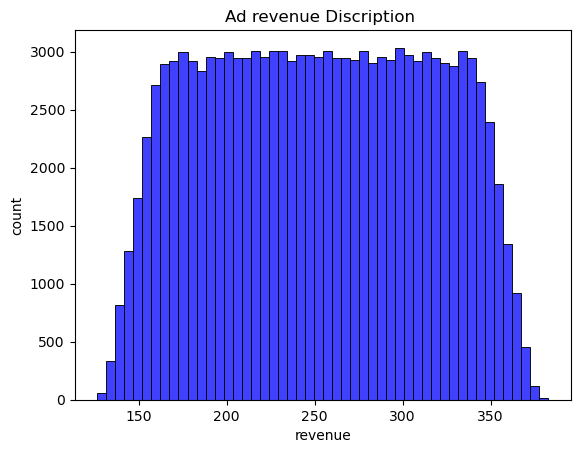

In [11]:
sns.histplot(df['ad_revenue_usd'],bins=50,color='blue')
plt.title('Ad revenue Discription ')
plt.xlabel('revenue')
plt.ylabel("count")
plt.show()

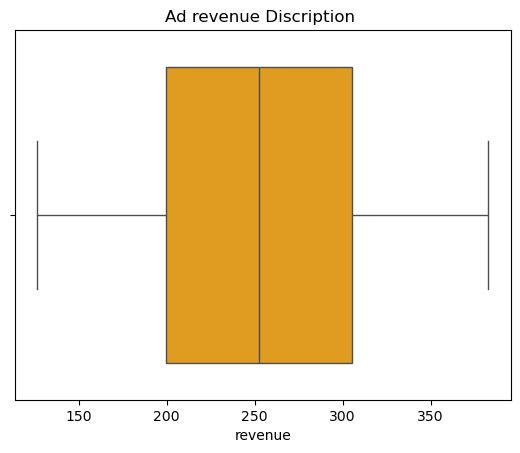

In [12]:
sns.boxplot(x=df['ad_revenue_usd'],color='orange')
plt.title('Ad revenue Discription ')
plt.xlabel('revenue')
plt.show()

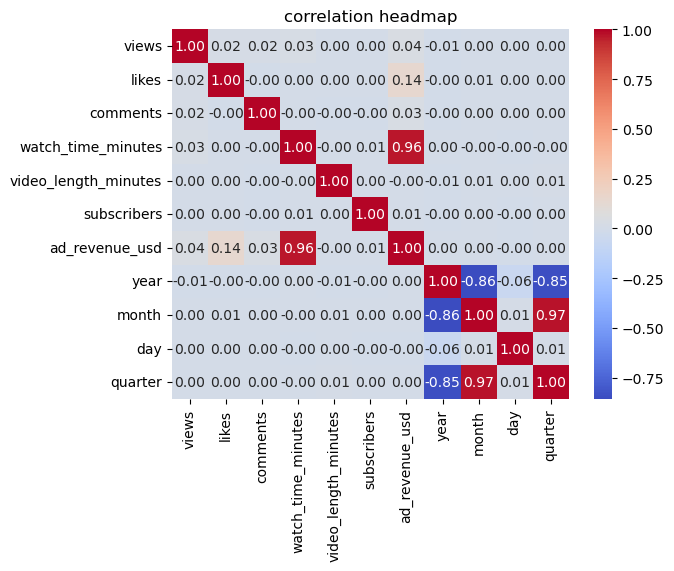

In [13]:
sns.heatmap(df.corr(numeric_only=True),annot=True,fmt='.2f',cmap='coolwarm')
plt.title('correlation headmap')
plt.show()

In [10]:
df.drop(columns=['quarter'], inplace=True)

In [11]:
df['watch_revenue_interaction'] = df['watch_time_minutes'] * df['ad_revenue_usd']

In [12]:
df['like_rate'] = df['likes'] / (df['views'] + 1)

In [13]:
import numpy as np
for col in ['views', 'likes', 'comments', 'ad_revenue_usd']:
    df[f'log_{col}'] = np.log1p(df[col])

In [14]:
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

In [15]:
cat_rev = df.groupby('category')['ad_revenue_usd'].mean().sort_values(ascending=False)
sns.barplot(x=cat_rev.index,y=cat_rev.values,palette='viridis')
plt.title("cat_wies")
plt.xlabel('cat')
plt.ylabel('avg_ren')
plt.xticks(rotation =45)

NameError: name 'sns' is not defined

C:\Users\gurus\AppData\Local\Temp\ipykernel_16764\993466302.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_rev.index,y=cat_rev.values,palette='viridis')


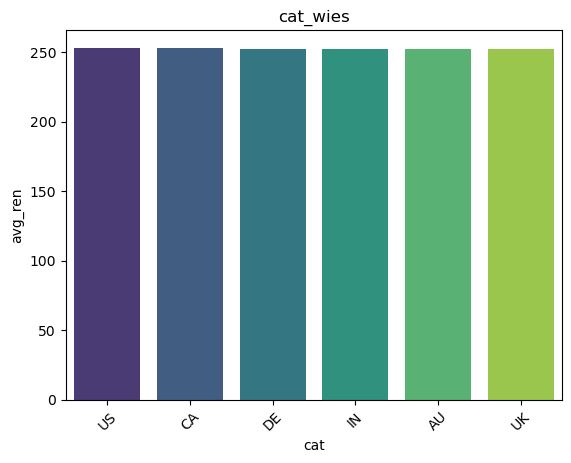

In [20]:
cat_rev = df.groupby('country')['ad_revenue_usd'].mean().sort_values(ascending=False)
sns.barplot(x=cat_rev.index,y=cat_rev.values,palette='viridis')
plt.title("cat_wies")
plt.xlabel('cat')
plt.ylabel('avg_ren')
plt.xticks(rotation =45)
plt.show()

C:\Users\gurus\AppData\Local\Temp\ipykernel_16764\4209302936.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_rev.index,y=cat_rev.values,palette='viridis')


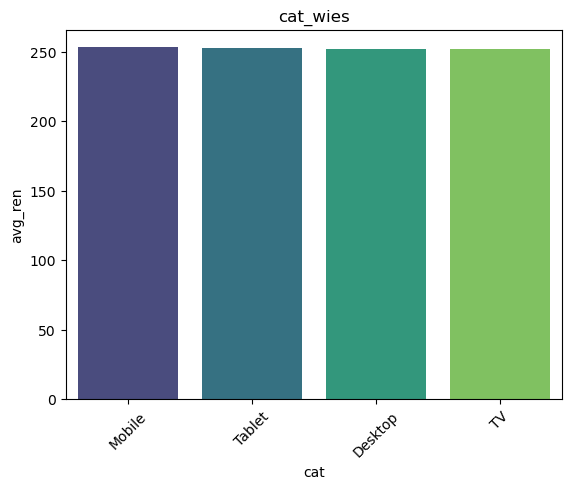

In [21]:
cat_rev = df.groupby('device')['ad_revenue_usd'].mean().sort_values(ascending=False)
sns.barplot(x=cat_rev.index,y=cat_rev.values,palette='viridis')
plt.title("cat_wies")
plt.xlabel('cat')
plt.ylabel('avg_ren')
plt.xticks(rotation =45)
plt.show()

In [22]:
df.head(2)

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd,...,month,day,watch_revenue_interaction,like_rate,log_views,log_likes,log_comments,log_ad_revenue_usd,month_sin,month_cos
0,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237,...,9,24,5.383657e+06,0.122874,9.204020,7.108244,5.771441,5.318993,-1.0,-1.836970e-16
1,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508,...,9,22,2.142757e+06,0.064085,9.212139,6.466145,5.849325,4.954985,-1.0,-1.836970e-16


In [34]:
print(df.columns.tolist())

['views', 'likes', 'comments', 'watch_time_minutes', 'video_length_minutes', 'subscribers', 'category', 'device', 'country', 'ad_revenue_usd', 'year', 'month', 'day', 'watch_revenue_interaction', 'like_rate', 'log_views', 'log_likes', 'log_comments', 'log_ad_revenue_usd', 'month_sin', 'month_cos']


In [31]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

# Step 1: Feature Engineering
df['log_ad_revenue_usd'] = np.log1p(df['ad_revenue_usd'])
df['like_rate'] = df['likes'] / (df['views'] + 1)
df['comment_rate'] = df['comments'] / (df['views'] + 1)

for col in ['views', 'likes', 'comments']:
    df[f'log_{col}'] = np.log1p(df[col])

# Step 2: 5 Features மட்டும்
X = df[['watch_time_minutes',
        'log_likes',
        'like_rate',
        'video_length_minutes',
        'log_views']]

y = df['log_ad_revenue_usd']

# Step 3: Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 4: Train
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Step 5: Evaluate
y_pred = model.predict(X_test)
y_pred_actual = np.expm1(y_pred)
y_test_actual = np.expm1(y_test)

print(f'MAE  : {mean_absolute_error(y_test_actual, y_pred_actual):.2f}')
print(f'R²   : {r2_score(y_test_actual, y_pred_actual):.4f}')

# Step 6: Save
joblib.dump(model, 'final_ads_revenue_model.pkl')
print("Model Saved! ✅")

MAE  : 5.25
R²   : 0.9436
Model Saved! ✅


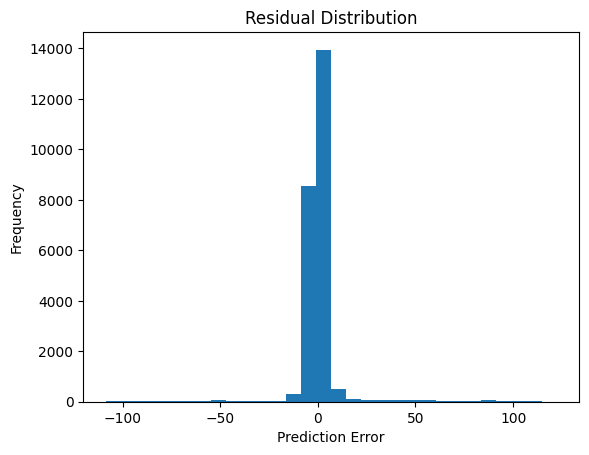

In [63]:
residuals = y_test_actual - y_pred_actual

import matplotlib.pyplot as plt

plt.hist(residuals, bins=30)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

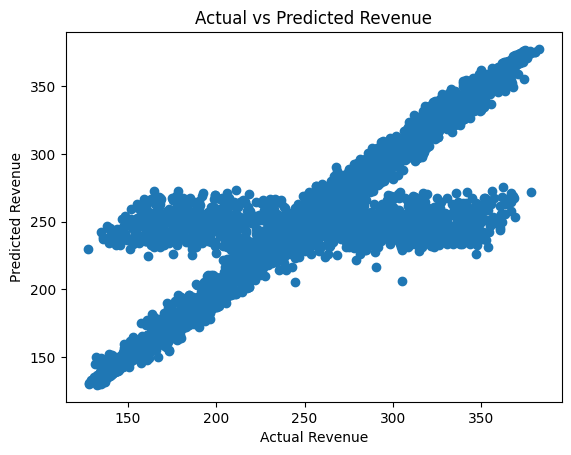

In [64]:
plt.scatter(y_test_actual, y_pred_actual)
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted Revenue")
plt.show()

In [65]:
print(residuals.describe())

count    24480.000000
mean         0.455659
std         14.412895
min       -108.604506
25%         -2.004876
50%          0.167634
75%          2.313780
max        122.251224
Name: log_ad_revenue_usd, dtype: float64


In [34]:
print(f'MAE  : {mean_absolute_error(y_test_actual, y_pred_actual):.2f}')
print(f'R²   : {r2_score(y_test_actual, y_pred_actual):.4f}')

MAE  : 4.00
R²   : 0.9461


In [33]:
# Negative values இருக்கான்னு check
print(df['ad_revenue_usd'].min())
print(df[df['ad_revenue_usd'] < 0].shape[0])

126.59060343135118
0


In [66]:
print(comparison.head(10))

            Actual   Predicted
20821   203.657208  203.134636
43046   168.354889  164.903114
111132  226.178045  228.008166
109329  239.419450  239.561110
43598   206.778367  203.363529
97830   338.261750  335.318891
118531  332.685829  349.474964
4232    338.236816  325.991208
82958   262.445600  262.170162
45412   300.005463  298.893568


In [44]:
print(df['ad_revenue_usd'].describe())

count    122400.000000
mean        252.727210
std          61.957052
min         126.590603
25%         199.902018
50%         252.749699
75%         305.597518
max         382.768254
Name: ad_revenue_usd, dtype: float64


In [1]:
df['ad_revenue_usd'] = df['ad_revenue_usd'] / 50

NameError: name 'df' is not defined

                feature  importance
0    watch_time_minutes    0.937060
2             log_likes    0.022018
4             like_rate    0.010112
8  video_length_minutes    0.007935
1             log_views    0.007032
5          comment_rate    0.005548
3          log_comments    0.004932
7             month_cos    0.002756
6             month_sin    0.002607


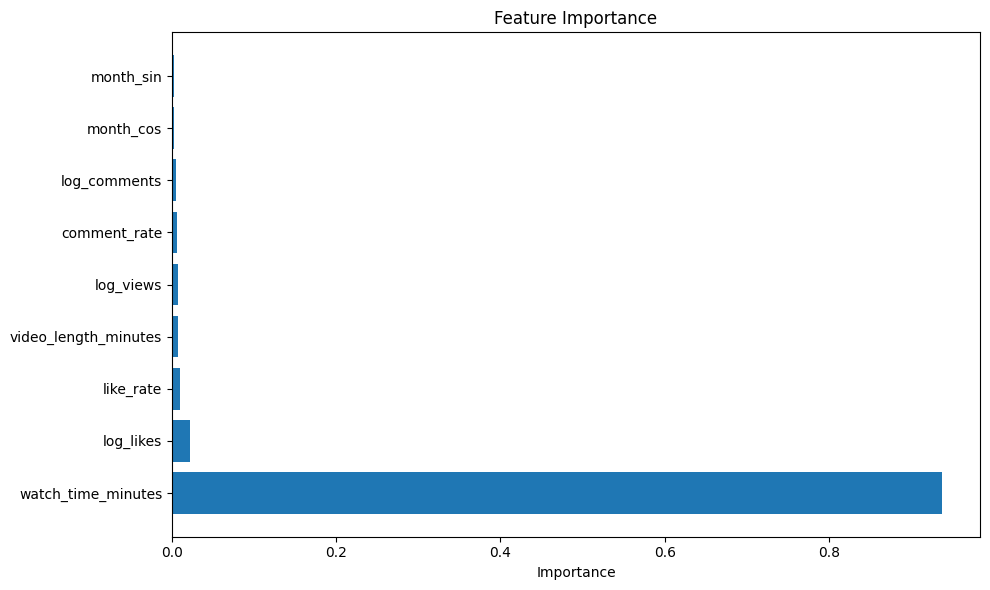

In [45]:
import matplotlib.pyplot as plt

# Feature Importance எடுக்கோம்
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance)

# Graph போடோம்
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], 
         feature_importance['importance'])
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [46]:
# Simple features மட்டும் வச்சுக்கோம்
X_simple = df[['watch_time_minutes', 
               'log_likes',
               'like_rate',
               'video_length_minutes',
               'log_views']]

y = df['log_ad_revenue_usd']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

# Model Train
model_simple = RandomForestRegressor(n_estimators=100, random_state=42)
model_simple.fit(X_train, y_train)

# Predict & Evaluate
y_pred = model_simple.predict(X_test)

y_pred_actual = np.expm1(y_pred)
y_test_actual = np.expm1(y_test)

print(f'MAE  : {mean_absolute_error(y_test_actual, y_pred_actual):.2f}')
print(f'R²   : {r2_score(y_test_actual, y_pred_actual):.4f}')

MAE  : 5.25
R²   : 0.9437


In [47]:
importance = pd.DataFrame({
    'Feature': X_simple.columns,
    'Importance': model_simple.feature_importances_
})

print(importance.sort_values(by='Importance', ascending=False))

                Feature  Importance
0    watch_time_minutes    0.940337
1             log_likes    0.024316
2             like_rate    0.012882
3  video_length_minutes    0.011919
4             log_views    0.010546


In [48]:
comparison = pd.DataFrame({
    'Actual': y_test_actual,
    'Predicted': y_pred_actual
})

print(comparison.head(10))

            Actual   Predicted
20821   203.657208  203.134636
43046   168.354889  164.903114
111132  226.178045  228.008166
109329  239.419450  239.561110
43598   206.778367  203.363529
97830   338.261750  335.318891
118531  332.685829  349.474964
4232    338.236816  325.991208
82958   262.445600  262.170162
45412   300.005463  298.893568


In [49]:
print("Train Score:", model_simple.score(X_train, y_train))
print("Test Score :", model_simple.score(X_test, y_test))

Train Score: 0.9924545101711126
Test Score : 0.9431537818805523


In [50]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 1.0/101.7 MB 3.9 MB/s eta 0:00:26
    --------------------------------------- 1.8/101.7 MB 3.5 MB/s eta 0:00:29
   - -------------------------------------- 3.1/101.7 MB 4.3 MB/s eta 0:00:23
   - -------------------------------------- 4.5/101.7 MB 4.8 MB/s eta 0:00:21
   -- ------------------------------------- 5.8/101.7 MB 5.1 MB/s eta 0:00:19
   -- ------------------------------------- 7.3/101.7 MB 5.4 MB/s eta 0:00:18
   --- ------------------------------------ 8.7/101.7 MB 5.5 MB/s eta 0:00:17
   --- ------------------------------------ 10.0/101.7 MB 5.6 MB/s eta 0:00:17
   ---- ----------------------------------- 11.3/101.7 MB 5.7 MB/s eta 0:00:16
   ----- ---------------------------------- 12.8/101.7 MB 5.8 MB/s eta 0:00:


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [51]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# Model
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

# Train
xgb_model.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test)

# Convert back
y_pred_actual = np.expm1(y_pred_xgb)
y_test_actual = np.expm1(y_test)

# Metrics
print("MAE :", mean_absolute_error(y_test_actual, y_pred_actual))
print("R²  :", r2_score(y_test_actual, y_pred_actual))

MAE : 5.046669437305464
R²  : 0.9457727426533109


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# ✅ Step 1: Feature Engineering
df.drop(columns=['quarter'], inplace=True)

# Engagement rates
df['like_rate'] = df['likes'] / (df['views'] + 1)
df['comment_rate'] = df['comments'] / (df['views'] + 1)

# Log transform
for col in ['views', 'likes', 'comments', 'ad_revenue_usd']:
    df[f'log_{col}'] = np.log1p(df[col])

# Cyclical encoding
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# ✅ Step 2: Features & Target split
X = df[['watch_time_minutes', 'log_views', 'log_likes',
        'log_comments', 'like_rate', 'comment_rate',
        'month_sin', 'month_cos', 'video_length_minutes']]

y = df['log_ad_revenue_usd']  # log transform பண்ணோம்!

# ✅ Step 3: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ✅ Step 4: Model Train
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# ✅ Step 5: Predict & Evaluate
y_pred = model.predict(X_test)

# Log-ஐ திரும்ப original-ஆ மாத்தோம்
y_pred_actual = np.expm1(y_pred)
y_test_actual = np.expm1(y_test)

print(f'MAE  : {mean_absolute_error(y_test_actual, y_pred_actual):.2f}')
print(f'R²   : {r2_score(y_test_actual, y_pred_actual):.4f}')

In [52]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

print(importance.sort_values(by='Importance', ascending=False))

                Feature  Importance
0    watch_time_minutes    0.937060
2             log_likes    0.022018
4             like_rate    0.010112
8  video_length_minutes    0.007935
1             log_views    0.007032
5          comment_rate    0.005548
3          log_comments    0.004932
7             month_cos    0.002756
6             month_sin    0.002607


In [53]:
print(f"Train R²: {model.score(X_train, y_train):.4f}")
print(f"Test R² : {model.score(X_test, y_test):.4f}")

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- comment_rate
- log_comments
- month_cos
- month_sin
